# Analyse Feldman Cousins
## Analyse the uncertainty of $s_i$ using the Feldman Cousins method

### Generator values of $s_i$

In [1]:
std::vector<double> Generator_si{-0.20, -0.21, 0.54, -0.40};

### Increment and steps in each direction

In [2]:
const double Increment = 0.1;
const std::map<int, std::pair<int, int>> Steps{
    {1, {-8, 4}},
    {2, {-5, 5}},
    {3, {-7, 5}},
    {4, {-5, 7}}
};

### Function for loading data scan

In [3]:
std::vector<std::pair<double, double> > GetDataScan(std::size_t Parameter) {
    std::string Filename("/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins/cisiFit/");
    Filename += "FeldmanCousinsDataScan_" + std::to_string(Parameter) + ".txt";
    std::ifstream File(Filename);
    std::string Line;
    std::vector<std::pair<double, double>> DataScan;
    while(std::getline(File, Line)) {
        if(Line.empty()) {
            continue;
        }
        double si, chi2;
        std::stringstream ss(Line);
        ss >> si >> chi2;
        DataScan.push_back({si, chi2});
    }
    File.close();
    return DataScan;
}

### Function for finding $\Delta\chi^2$ in toy

In [4]:
std::vector<double> GetToyDeltaChi2(const std::string &ToyName) {
    std::vector<double> DeltaChi2Values;
    std::string Filename("/data/bes3/tat/KKpipi_StrongPhase_Analysis_4Bins/cisiFit/FeldmanCousinsResults/");
    for(std::size_t i = 0; i < 1000; i++) {
        std::ifstream File(Filename + ToyName + std::to_string(i) + ".txt");
        if(!File.is_open()) {
            continue;
        }
        double DeltaChi2;
        File >> DeltaChi2;
        if(DeltaChi2 < 0.0) {
            continue;
        }
        DeltaChi2Values.push_back(DeltaChi2);
        File.close();
    }
    return DeltaChi2Values;
}

### Get p-value

In [5]:
double GetPValue(double Chi2Data, const std::vector<double> &ToyChi2Values) {
    std::size_t BadToys = std::count_if(ToyChi2Values.begin(),
                                        ToyChi2Values.end(),
                                        [=] (double a) { return a > Chi2Data; });
    std::size_t NumberToys = std::count_if(ToyChi2Values.begin(),
                                           ToyChi2Values.end(),
                                           [] (double a) { return a > 0; });
    return static_cast<double>(BadToys)/NumberToys;
}

### Get the $\chi^2$ difference found in data

In [6]:
double GetDataChi2(double si, std::size_t Parameter) {
    const auto DataScan = GetDataScan(Parameter);
    for(const auto &DataPoint : DataScan) {
        if(TMath::Abs(si - DataPoint.first) < 0.000001) {
            return DataPoint.second;
        }
    }
    std::cout << "Could not find si value " << si << "\n";
    return -1.0;
}

### Function for scanning over the asymmetric Gaussian and finding confidence levels numerically

In [7]:
std::pair<std::vector<double>, std::vector<double> > ScanAsymmetricCL(
    double Value, double MinusErr, double PlusErr
) {
    // Get the asymmetric Gaussian function boundaries
    const double xMin =
        (MinusErr < PlusErr) ? (Value - (PlusErr*MinusErr)/(PlusErr - MinusErr)) : (Value - 7.0*MinusErr);
    const double xMax =
        (MinusErr < PlusErr) ? (Value + 7.0*PlusErr) : (Value + PlusErr*MinusErr/(MinusErr - PlusErr));
    // The asymmetric Gaussian
    auto AsymmetricGauss = [] (double *x, double *p) {
        // x[0]: Function value
        // p[0]: Central value
        // p[1]: Negative uncertainty
        // p[2]: Positive uncertainty
        const double Std2 = p[1]*p[2];
        const double StdDiff = p[1] - p[2];
        const double xDiff = p[0] - x[0];
        const double Var = Std2 + StdDiff*xDiff;
        return TMath::Exp(-(xDiff*xDiff)/(2.0*Var));
    };
    // Create the ROOT TF1 function so that we can integrate
    const std::array<double, 3> Params{Value, MinusErr, PlusErr};
    TF1 f1("f1", AsymmetricGauss, xMin, xMax, 3);
    f1.SetParameters(Params.data());
    // Total integral for normalisation
    const double TotalIntegral = f1.Integral(xMin, xMax);
    // Function for getting the bounds for a given function value
    auto GetBounds = [&] (double x) {
        double Lower = f1.GetX(x, xMin, Value);
        double Upper = f1.GetX(x, Value, xMax);
    return std::make_pair(Lower, Upper);
    };
    // Get the confidence level at a given function value
    auto GetCLIntegral = [&] (double x) {
        std::pair<double, double> Bounds = GetBounds(x);
        return 1.0 - f1.Integral(Bounds.first, Bounds.second)/TotalIntegral;
    };
    // Make a list of points
    std::vector<double> x_left, x_right, y_left, y_right;
    for(double i = 0.01; i < 1.0; i += 0.01) {
        std::pair<double, double> Bounds = GetBounds(i);
        x_left.push_back(Bounds.first);
        x_right.push_back(Bounds.second);
        y_left.push_back(GetCLIntegral(i));
        y_right.push_back(y_left.back());
    }
    x_right.push_back(Value);
    y_right.push_back(1.0);
    std::reverse(x_right.begin(), x_right.end());
    std::reverse(y_right.begin(), y_right.end());
    std::vector<double> x = x_left;
    std::vector<double> y = y_left;
    x.insert(x.end(), x_right.begin(), x_right.end());
    y.insert(y.end(), y_right.begin(), y_right.end());
    // Return lists
    return std::make_pair(x, y);
}

### Make plots of $1 - \text{CL}$

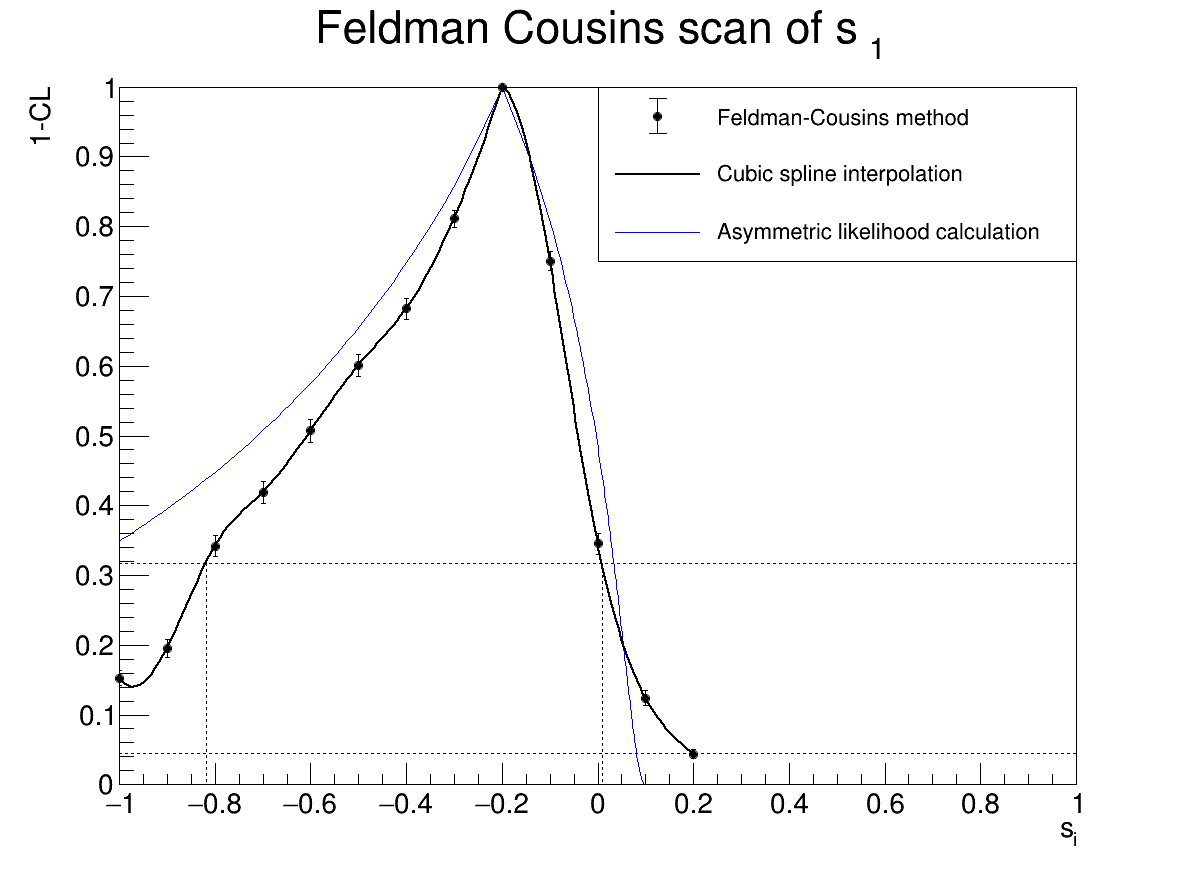

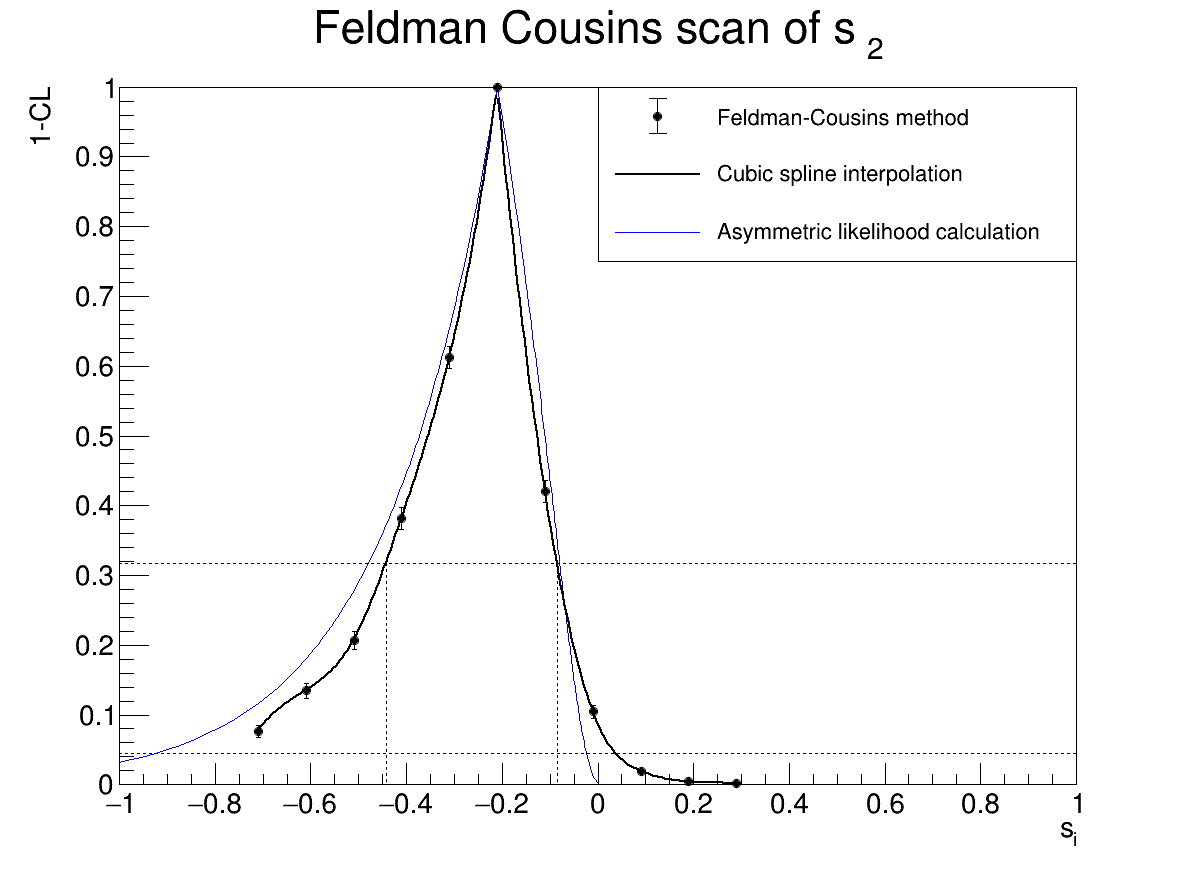

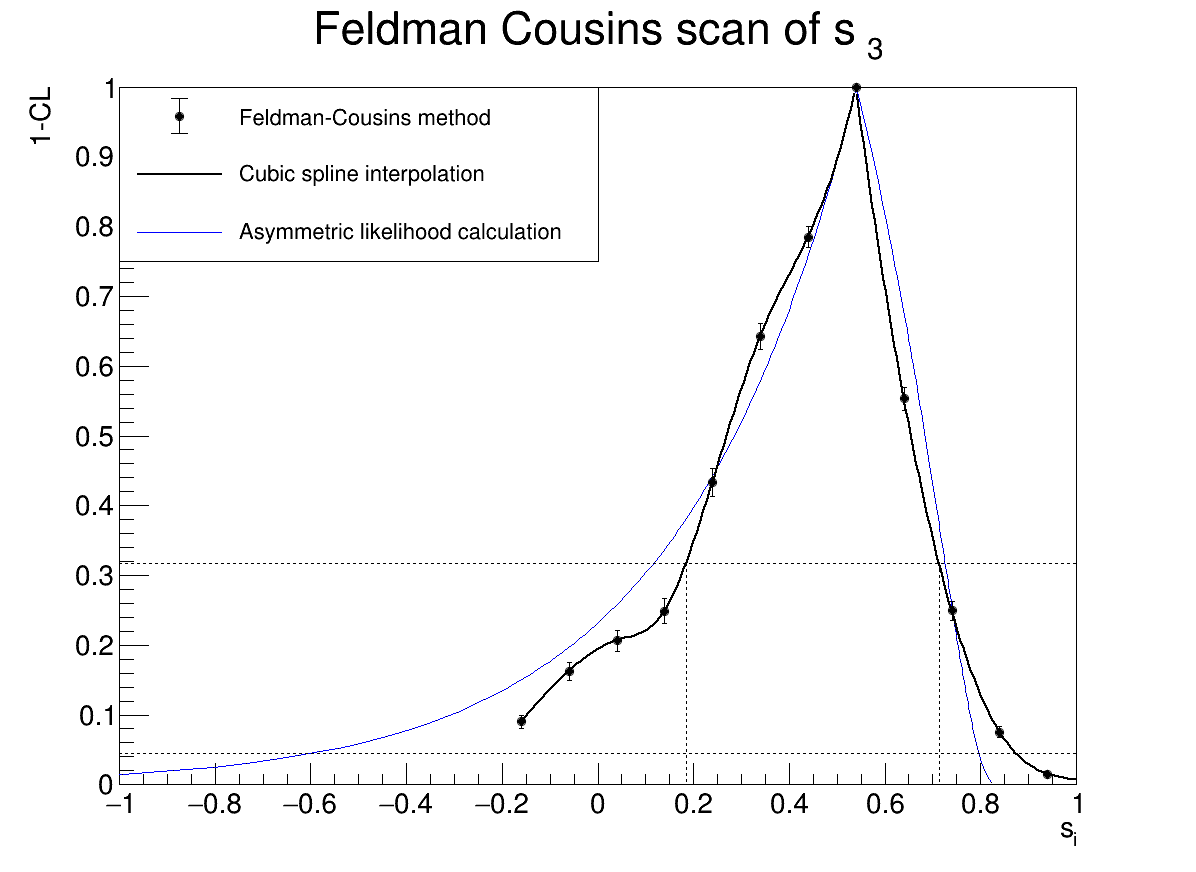

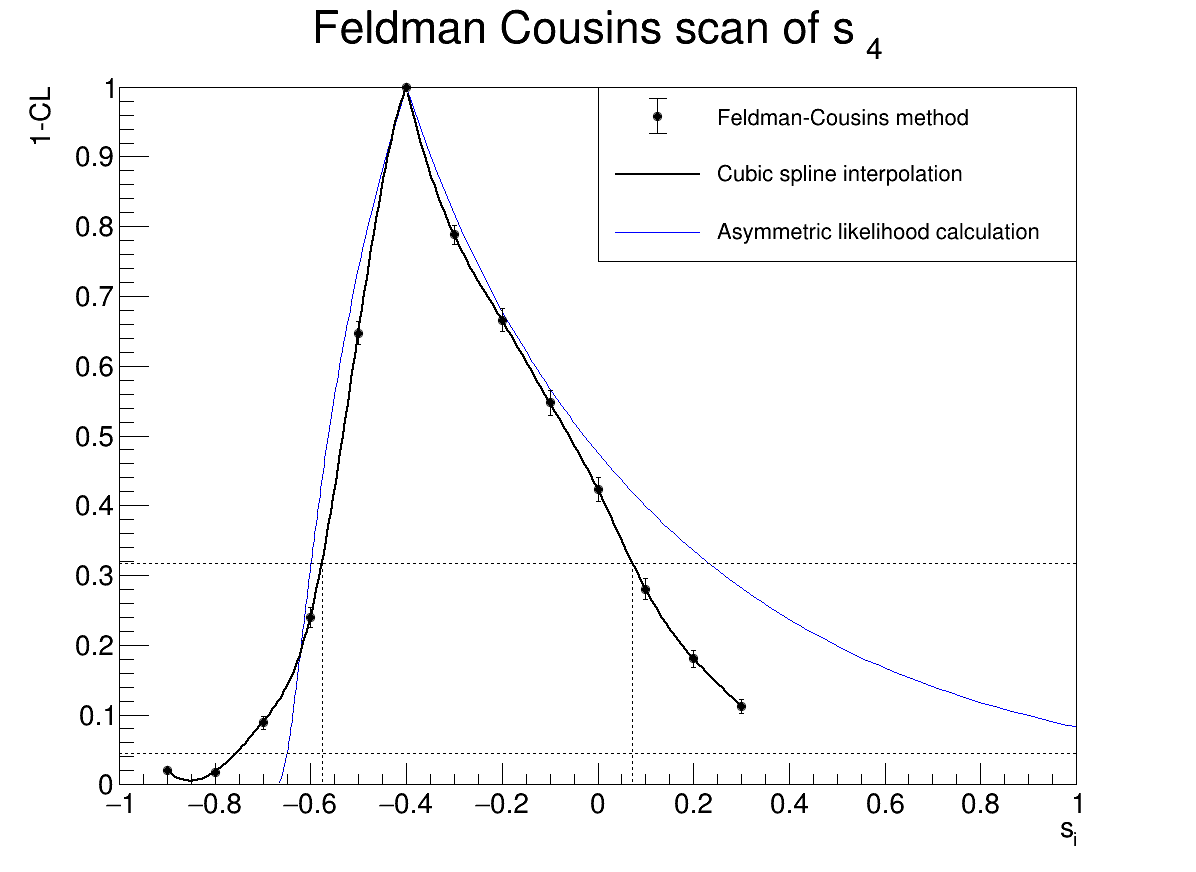

s_1 asymmetric uncertainty:
^{+0.21}_{-0.62}
s_1 asymmetric uncertainty:
^{+0.12}_{-0.23}
s_1 asymmetric uncertainty:
^{+0.17}_{-0.35}
s_1 asymmetric uncertainty:
^{+0.47}_{-0.18}


Info in <TCanvas::Print>: pdf file Feldman_Cousins_CL_s1.pdf has been created
Info in <TCanvas::Print>: pdf file Feldman_Cousins_CL_s2.pdf has been created
Info in <TCanvas::Print>: pdf file Feldman_Cousins_CL_s3.pdf has been created
Info in <TCanvas::Print>: pdf file Feldman_Cousins_CL_s4.pdf has been created


In [8]:
std::size_t Counter = 0;
for(std::size_t Parameter = 1; Parameter <= 4; Parameter++) {
    std::vector<double> x, y, y_err;
    std::vector<double> x_Plus_spline, y_Plus_spline, x_Minus_spline, y_Minus_spline;
    for(int i = Steps.at(Parameter).first; i <= Steps.at(Parameter).second; i++) {
        if(i == 0) {
            x.push_back(Generator_si[Parameter - 1]);
            y.push_back(1.0);
            y_err.push_back(0.0);
            x_Plus_spline.push_back(x.back());
            x_Minus_spline.push_back(x.back());
            y_Plus_spline.push_back(1.0);
            y_Minus_spline.push_back(1.0);
        } else {
            const double si = Generator_si[Parameter - 1] + i*Increment;
            x.push_back(si);
            auto DataChi2 = GetDataChi2(si, Parameter);
            std::string ToyName = "ScanParameter" + std::to_string(Parameter);
            ToyName += "_Increment" + std::string(i > 0 ? "P" : "M") + std::to_string(TMath::Abs(i));
            ToyName += "_GeneratorYields";
            auto ToyChi2Values = GetToyDeltaChi2(ToyName);
            y.push_back(GetPValue(DataChi2, ToyChi2Values));
            y_err.push_back(TMath::Sqrt(y.back()*(1.0 - y.back())/ToyChi2Values.size()));
            if(i > 0) {
                x_Plus_spline.push_back(x.back());
                y_Plus_spline.push_back(y.back());
            } else {
                x_Minus_spline.push_back(x.back());
                y_Minus_spline.push_back(y.back());
            }
        }
    }
    /*for(std::size_t j = 0; j < x.size(); j++) {
        std::cout << x[j] << " " << y[j] << " " << y_err[j] << "\n";
    }*/
    TGraphErrors *Graph = new TGraphErrors(x.size(), x.data(), y.data(), nullptr, y_err.data());
    TCanvas *c = new TCanvas(("c_" + std::to_string(Counter)).c_str(), "", 1200, 900);
    std::string Title("Feldman Cousins scan of s_{");
    Title += std::to_string(Parameter) + "};s_{i};1-CL";
    Graph->SetMarkerStyle(20);
    TLine *Sigma1 = new TLine(-1.0, TMath::Prob(1.0, 1), +1.0, TMath::Prob(1.0, 1));
    Sigma1->SetLineStyle(kDashed);
    TLine *Sigma2 = new TLine(-1.0, TMath::Prob(4.0, 1), +1.0, TMath::Prob(4.0, 1));
    Sigma2->SetLineStyle(kDashed);
    TSpline3 *PlusSpline = new TSpline3(("Spline_plus_" + std::to_string(Counter)).c_str(),
                                        x_Plus_spline.data(),
                                        y_Plus_spline.data(),
                                        x_Plus_spline.size());
    PlusSpline->SetLineWidth(2);
    auto PlusSplineEval = [&] (double *x, double *p) {
        return PlusSpline->Eval(x[0]);
    };
    double MinX = Generator_si[Parameter - 1] + Increment*Steps.at(Parameter).first;
    double MaxX = Generator_si[Parameter - 1] + Increment*Steps.at(Parameter).second;
    TF1 PlusSplineF(("f_plus_" + std::to_string(Counter)).c_str(),
                    PlusSplineEval, Generator_si[Parameter - 1], MaxX, 1);
    double PlusCL = PlusSplineF.GetX(TMath::Prob(1.0, 1), Generator_si[Parameter - 1], MaxX);
    TLine *VertPlus = new TLine(PlusCL, 0.0, PlusCL, TMath::Prob(1.0, 1));
    VertPlus->SetLineStyle(kDashed);
    TSpline3 *MinusSpline = new TSpline3(("Spline_minus_" + std::to_string(Counter)).c_str(),
                                         x_Minus_spline.data(),
                                         y_Minus_spline.data(),
                                         x_Minus_spline.size());
    MinusSpline->SetLineWidth(2);
    auto MinusSplineEval = [&] (double *x, double *p) {
        return MinusSpline->Eval(x[0]);
    };
    TF1 MinusSplineF(("f_minus_" + std::to_string(Counter++)).c_str(),
                     MinusSplineEval, MinX, Generator_si[Parameter - 1], 1);
    double MinusCL = MinusSplineF.GetX(TMath::Prob(1.0, 1), MinX, Generator_si[Parameter - 1]);
    TLine *VertMinus = new TLine(MinusCL, 0.0, MinusCL, TMath::Prob(1.0, 1));
    VertMinus->SetLineStyle(kDashed);
    double PlusErr = PlusCL - Generator_si[Parameter - 1];
    PlusErr = std::round(PlusErr*100.0)/100.0;
    double MinusErr = Generator_si[Parameter - 1] - MinusCL;
    MinusErr = std::round(MinusErr*100.0)/100.0;
    auto Points = ScanAsymmetricCL(Generator_si[Parameter - 1], MinusErr, PlusErr);
    TGraph *GraphAsymmGauss = new TGraph(Points.first.size(), Points.first.data(), Points.second.data());
    GraphAsymmGauss->SetLineColor(kBlue);
    GraphAsymmGauss->SetTitle(Title.c_str());
    GraphAsymmGauss->SetMinimum(0.0);
    GraphAsymmGauss->SetMaximum(1.0);
    GraphAsymmGauss->GetXaxis()->SetLimits(-1.0, 1.0);
    GraphAsymmGauss->Draw("ALP");
    Graph->Draw("P SAME");
    Sigma1->Draw("SAME");
    Sigma2->Draw("SAME");
    PlusSpline->Draw("SAME");
    VertPlus->Draw("SAME");
    MinusSpline->Draw("SAME");
    VertMinus->Draw("SAME");
    TLegend *Legend = nullptr;
    if(Parameter == 3) {
        Legend = new TLegend(0.1, 0.7, 0.5, 0.9);
    } else {
        Legend = new TLegend(0.5, 0.7, 0.9, 0.9);
    }
    Legend->AddEntry(Graph, "Feldman-Cousins method", "PE");
    Legend->AddEntry(MinusSpline, "Cubic spline interpolation", "L");
    Legend->AddEntry(GraphAsymmGauss, "Asymmetric likelihood calculation", "L");
    Legend->Draw();
    c->Draw();
    c->SaveAs(("Feldman_Cousins_CL_s" + std::to_string(Parameter) + ".pdf").c_str());
    std::cout << "s_1 asymmetric uncertainty:\n";
    std::cout << "^{+";
    std::cout << std::fixed << std::setprecision(2) << PlusErr << "}_{-";
    std::cout << std::fixed << std::setprecision(2) << MinusErr << "}\n";
}